Dataset Loaded Successfully
                 Dates        Category                      Descript  \
0  2015-05-13 23:53:00        WARRANTS                WARRANT ARREST   
1  2015-05-13 23:53:00  OTHER OFFENSES      TRAFFIC VIOLATION ARREST   
2  2015-05-13 23:33:00  OTHER OFFENSES      TRAFFIC VIOLATION ARREST   
3  2015-05-13 23:30:00   LARCENY/THEFT  GRAND THEFT FROM LOCKED AUTO   
4  2015-05-13 23:30:00   LARCENY/THEFT  GRAND THEFT FROM LOCKED AUTO   

   DayOfWeek PdDistrict      Resolution                    Address  \
0  Wednesday   NORTHERN  ARREST, BOOKED         OAK ST / LAGUNA ST   
1  Wednesday   NORTHERN  ARREST, BOOKED         OAK ST / LAGUNA ST   
2  Wednesday   NORTHERN  ARREST, BOOKED  VANNESS AV / GREENWICH ST   
3  Wednesday   NORTHERN            NONE   1500 Block of LOMBARD ST   
4  Wednesday       PARK            NONE  100 Block of BRODERICK ST   

            X          Y  
0 -122.425892  37.774599  
1 -122.425892  37.774599  
2 -122.424363  37.800414  
3 -122.426

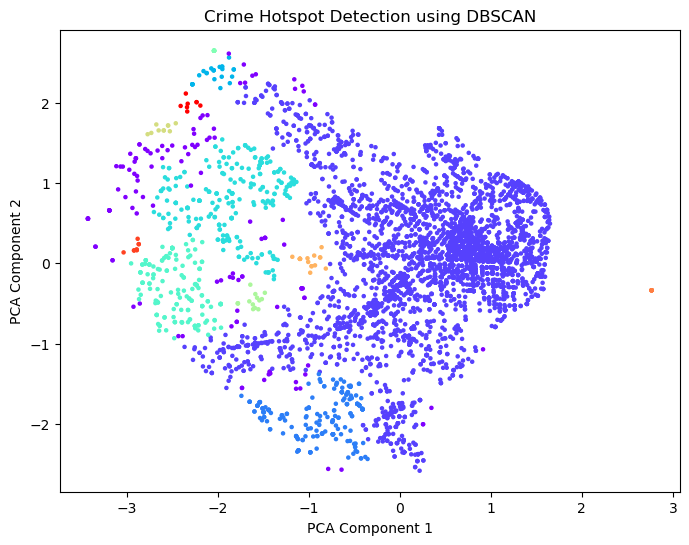

Number of crime hotspots detected: 12
Noise points: 124


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Use only first 5000 rows so the algorithm runs fast
data = pd.read_csv("train.csv").head(5000)
print("Dataset Loaded Successfully")
print(data.head())
X = data[['X','Y']]
# Remove invalid coordinates
X = X[X['Y'] != 90]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
dbscan = DBSCAN(eps=0.15, min_samples=8)
clusters = dbscan.fit_predict(X_scaled)

print("Cluster Labels:", set(clusters))
data = data.iloc[:len(clusters)]
data['Cluster'] = clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='rainbow',
    s=5
)
plt.title("Crime Hotspot Detection using DBSCAN")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()
num_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print("Number of crime hotspots detected:", num_clusters)
print("Noise points:", list(clusters).count(-1))